REGIME DETECTION - VOLATILITY BASED METHOD (#1)

Regime distribution:
  Trending: 619 days (50.0%)
  Mean Reversion: 619 days (50.0%)

Number of regime switches: 34
Average days per regime: 36.4

 Saved to data/spy_with_regimes.csv


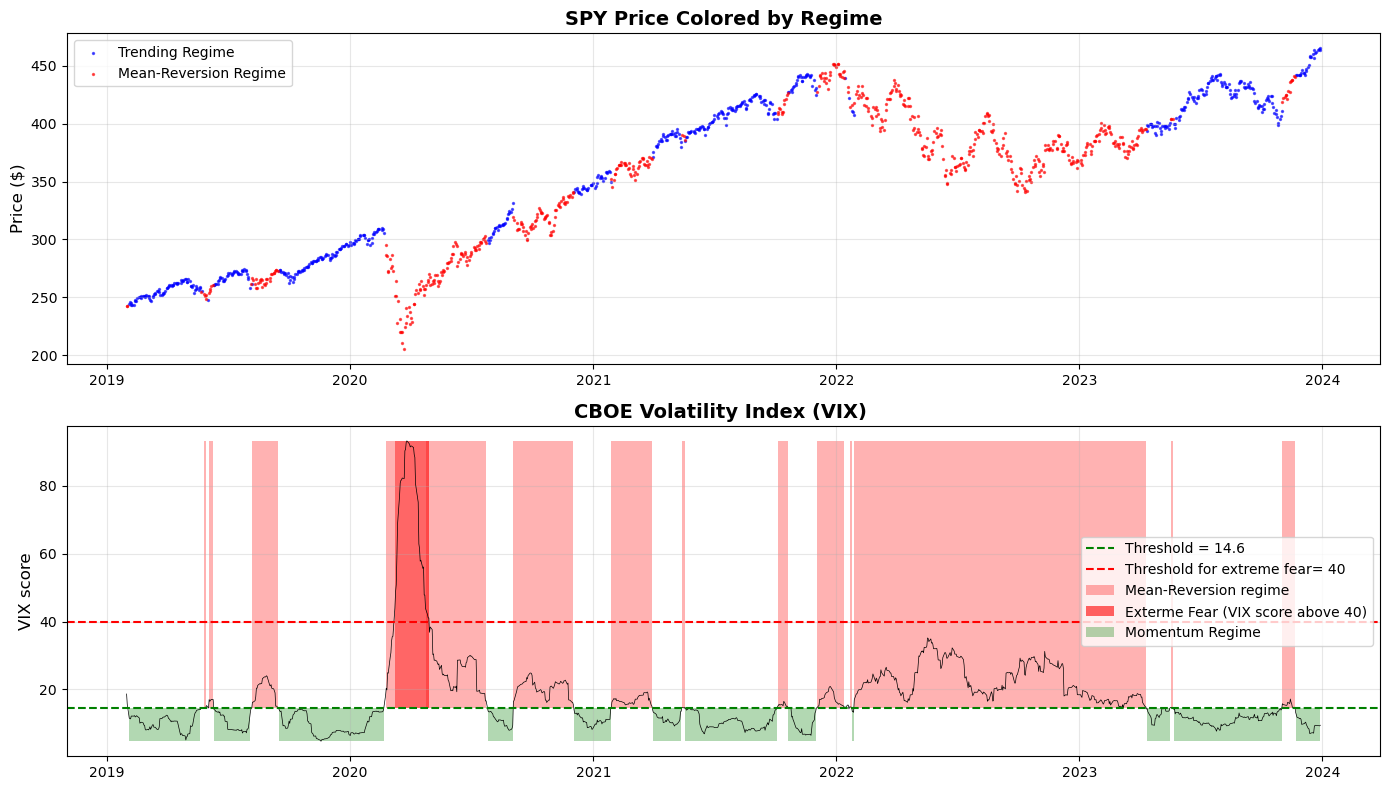


 VIX SCORE: ANNUALIZED VOLATILITY % THAT ARE FREQUENTLY USED TO ASSES MARKET SENTIMENT AND RISK! 

REGIME DETECTION COMPLETE!


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#VOLATILITY BASED

print("=" *50)
print('REGIME DETECTION - VOLATILITY BASED METHOD (#1)')
print("=" *50)

data = pd.read_csv('data/spy_processed.csv', index_col = 'Date', parse_dates = True) 
data['volatility'] = data['volatility'] * np.sqrt(252) * 100 #conversion of daily std/vol to vix score
threshold = data['volatility'].median()

#Creating a regime column
data['regime'] = np.where(
    data['volatility'] > threshold,
    'Mean_Reversion', 
    'Trending')

regime_counts = data['regime'].value_counts()

print(f"\nRegime distribution:")
print(f"  Trending: {regime_counts.get('Trending', 0)} days ({regime_counts.get('Trending', 0)/len(data)*100:.1f}%)")
print(f"  Mean Reversion: {regime_counts.get('Mean_Reversion', 0)} days ({regime_counts.get('Mean_Reversion', 0)/len(data)*100:.1f}%)")

switches = (data['regime'] != data['regime'].shift()).sum()
print(f"\nNumber of regime switches: {switches}")
print(f"Average days per regime: {len(data) / switches:.1f}")

#Creating Data file with regimes
data.to_csv('data/spy_with_regimes.csv')
print(f"\n Saved to data/spy_with_regimes.csv")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

trending_mask = data['regime'] == 'Trending'
meanrev_mask = data['regime'] == 'Mean_Reversion'

axes[0].scatter(data[trending_mask].index, data[trending_mask]['Close'], c='blue', s=2, alpha=0.6, label='Trending Regime')
axes[0].scatter(data[meanrev_mask].index, data[meanrev_mask]['Close'], c='red', s=2, alpha=0.6, label='Mean-Reversion Regime')
axes[0].set_title('SPY Price Colored by Regime', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(data.index, data['volatility'], c = 'black', linewidth = 1/2)
axes[1].axhline( y= threshold, c= 'green', linestyle ='dashed', label=f'Threshold = {threshold:.1f}')   
axes[1].axhline( y= 40, c= 'red', linestyle ='dashed', label=f'Threshold for extreme fear= 40')   
axes[1].fill_between (data.index, threshold, data ['volatility'].max(), where = (data['volatility'] > threshold) & (data['volatility']<= 45) , alpha =  0.3, color='red',linewidth = 0, label = 'Mean-Reversion regime')
axes[1].fill_between (data.index, threshold, data ['volatility'].max(), where = data['volatility'] >= 40, alpha =  0.6, color='r',linewidth = 0, label = 'Exterme Fear (VIX score above 40)')
axes[1].fill_between (data.index, threshold,data ['volatility'].min() , where = data['volatility'] < threshold, alpha = 0.3, color = 'green', linewidth = 0, label = 'Momentum Regime')
axes[1].set_title ('CBOE Volatility Index (VIX) ', fontsize = 14, fontweight = 'bold')
axes[1].set_ylabel('VIX score', fontsize  = 12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/regime_detection_volatility.png', dpi=300, bbox_inches='tight')

plt.show()
print("="*50)
print("\n" +' VIX SCORE: ANNUALIZED VOLATILITY % THAT ARE FREQUENTLY USED TO ASSES MARKET SENTIMENT AND RISK! ')
print("\n" + "="*50)
print("REGIME DETECTION COMPLETE!")
print("="*50)